# Replacing TF-IDF with CountVectorizer

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"IMDB-Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [5]:
df = df.drop_duplicates()

In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 49582 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     49582 non-null  str  
 1   sentiment  49582 non-null  str  
dtypes: str(2)
memory usage: 63.5 MB


In [8]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [10]:
X = df['review']
y = df['sentiment']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20, stratify = y)

In [14]:
model = Pipeline([
    (
        "Count_Vectorizer",
        CountVectorizer(
            binary = True,
            max_features = 15000
        )
    ),
    (
        "Classifier",
        LogisticRegression(
            max_iter = 300,
            solver = "liblinear"
        )
    )
])

In [16]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Count_Vectorizer', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['negative','positive']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",15000
,"binary binary: bool, default=FalseIf True, all non zero counts are set to 1. This is useful for discreteprobabilistic models that model binary events rather than integercounts.",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Count_Vectorizer', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['negative','positive']"
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",15000
,"binary binary: bool, default=FalseIf True, all non zero counts are set to 1. This is useful for discreteprobabilistic models that model binary events rather than integercounts.",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [18]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

In [22]:
print("Accuracy score: ", accuracy)
print()
print("Classification Report: ")
print(classification_report(y_test, y_pred))
print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))

Accuracy score:  0.8731471211051729

Classification Report: 
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87      4940
    positive       0.87      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917

Confusion Matrix: 
[[4301  639]
 [ 619 4358]]
Accuracy score:  0.8731471211051729

Classification Report: 
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87      4940
    positive       0.87      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917

Confusion Matrix: 
[[4301  639]
 [ 619 4358]]


## Comparison Table between TF_IDF and CountVectorizer

**TF-IDF:**

Accuracy: 89.56%

**CountVectorizer**

Accuracy: 87.31%

### Reviews that got wrong

In [24]:
results = pd.DataFrame({
    "review":  X_test,
    "actual": y_test,
    "predicted": y_pred
})

results.head()

,review,actual,predicted
35145,My wife and I watched this after DVR'ing it of...,negative,negative
18490,I was surprised how much I enjoyed this. Sure ...,positive,positive
4087,Such a delightful movie! Very heart warming. O...,positive,positive
28130,"""La Lupa Mannara"" aka. ""Werewolf Woman"" of 197...",negative,negative
3734,First this movie was not that bad.It was enter...,negative,negative


,review,actual,predicted
35145,My wife and I watched this after DVR'ing it of...,negative,negative
18490,I was surprised how much I enjoyed this. Sure ...,positive,positive
4087,Such a delightful movie! Very heart warming. O...,positive,positive
28130,"""La Lupa Mannara"" aka. ""Werewolf Woman"" of 197...",negative,negative
3734,First this movie was not that bad.It was enter...,negative,negative


In [26]:
mistakes = results[results['actual'] != results['predicted']]
mistakes.head()

,review,actual,predicted
45794,"This isn't exactly a great film, but I admire ...",positive,negative
34722,Despite being a huge fan of Fred Astaire and G...,negative,positive
27228,"Well, well....Roeg touched a bit of a nerve th...",positive,negative
14432,"I'm not here to tell you ""Armored"" is Kubricki...",positive,negative
44505,Well let's be fair. Following up a cult classi...,negative,positive


,review,actual,predicted
45794,"This isn't exactly a great film, but I admire ...",positive,negative
34722,Despite being a huge fan of Fred Astaire and G...,negative,positive
27228,"Well, well....Roeg touched a bit of a nerve th...",positive,negative
14432,"I'm not here to tell you ""Armored"" is Kubricki...",positive,negative
44505,Well let's be fair. Following up a cult classi...,negative,positive


In [28]:
mistakes.count()

review       1258
actual       1258
predicted    1258
dtype: int64

review       1258
actual       1258
predicted    1258
dtype: int64

In [30]:
for review, actual, predicted in zip(
    mistakes['review'].head(5),
    mistakes['actual'].head(5),
    mistakes['predicted'].head(5)
):
    print("Review: ", review)
    print("Actual: ", actual)
    print("Predicted", predicted)
    print("-" * 125)

Review:  This isn't exactly a great film, but I admire the writers and director for trying something a little different. The film's main theme is fate and small, seemingly insignificant things that can greatly change the future. In some ways this reminds me of the film SLIDING DOORS, though instead of focusing on one random event, seemingly random stuff happens repeatedly and each one helps build to the cute conclusion. Plus, an odd bald guy seems to understand all this and he talks about this during one brief scene--like he's some sort of omnipotent being but there's absolutely no explanation of him in the film (like the two guys that fight each other in the clock tower in THE HUDSUCKER PROXY).<br /><br />The DVD jacket shows just Audrey Tautou. This is capitalize on her success in AMELIE, though she is only one of many actors in the film and there is no one starring role. The pace is brisk, the acting fine and the conclusion isn't bad at all. The only reason I didn't score it higher 

### Adding a confusion matrix graph

In [32]:
# pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

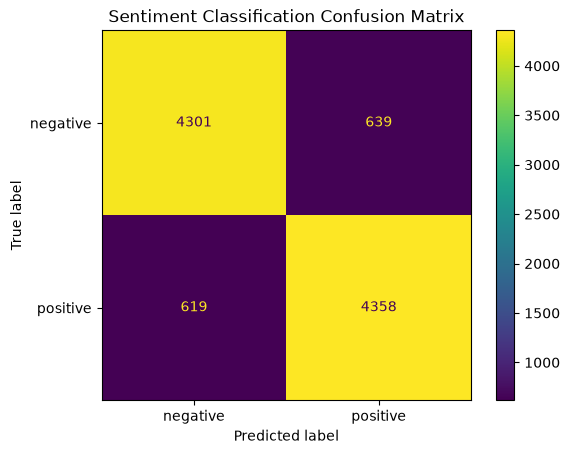

In [35]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Sentiment Classification Confusion Matrix")
plt.show()